# Spatial cell-type maps, ROI crops, and marker-intensity visualization

Adapted from `018_codex_vis_fusion_run45_Bella_clean_afteranndata.ipynb` to
run against `config.yaml` and `build_final_anndata.ipynb`'s output, instead
of hardcoded paths and a single hardcoded run/condition pair.

**Run this after `build_final_anndata.ipynb`.** It:
1. Projects `clusters_named` back onto each sample's spatial image (cells
   that didn't survive filtering are labeled `"Removed"` and colored gray),
   using `spatialproteomics`'s own plotting - this is different from the
   scanpy `sc.pl.spatial` sanity-check plot in `build_final_anndata.ipynb`
   and gives publication-style segmentation+label overlays.
2. Lets you crop and save specific regions of interest (ROIs).
3. Has example marker-intensity visualization/filtering cells.

**What changed vs. the original notebook:**
- Runs/conditions/samples/paths all come from `config.yaml` (via
  `scripts/py_config.py`), instead of a single hardcoded `run46` +
  `['EV','Thpo']`. The loop below now covers every run/sample in your config.
- Cell-type labels are re-attached using the same position-parsing logic as
  `build_final_anndata.ipynb` (`"<original_row_position>_<sample>"`),
  instead of manually reconstructing an index string.
- Marker names: `anndata.var_names` uses R-safe names (e.g.
  `"X127.CD61"`), but the raw `spatialproteomics` zarr objects use the
  original space-separated names from your marker list (e.g. `"127 CD61"`).
  A small `to_r_safe_name()` helper (mirrors R's `make.names()`) derives
  one from the other automatically, so you only ever type a marker name
  once - as it appears in `channels` (see below) - rather than maintaining
  two name lists that can drift out of sync.
- All hardcoded output paths (figures, per-sample CSVs) now go under
  `paths['visual_output_dir']` / `paths['pipeline_run']`.
- **ROI pixel coordinates, marker choices for the visualization section,
  and intensity-filtering thresholds are inherently specific to your own
  images and biology** - those are left as clearly-marked templates with
  the original notebook's values as examples, not generalized.


In [1]:
import os
import re
import sys
from glob import glob

import numpy as np
import pandas as pd
import spatialproteomics
import xarray as xr
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import warnings
warnings.filterwarnings("ignore")

import CODEX_analysis_helpers as cah

import gc
gc.collect()


20

## Patch `relabel_sequential` to force a writeable array copy

Carried over unchanged from the original notebook - a defensive fix for a
`spatialproteomics` bug where merged-segmentation label arrays can come
back as read-only memory views, which crashes label re-indexing.

In [2]:
orig_relabel = spatialproteomics.la.label.relabel_sequential

def writeable_relabel_sequential(label_field, offset=1):
    label_field_copy = np.array(label_field, copy=True, order="C")
    label_field_copy.setflags(write=True)
    return orig_relabel(label_field_copy, offset=offset)

spatialproteomics.la.label.relabel_sequential = writeable_relabel_sequential
if hasattr(spatialproteomics.la, "label_accessor"):
    spatialproteomics.la.label_accessor.relabel_sequential = writeable_relabel_sequential


## Load config.yaml (same config the rest of the pipeline uses)

In [3]:
CONFIG_PATH = "./config.yaml"       # <-- adjust if this notebook lives elsewhere
PIPELINE_SCRIPTS_DIR = "./scripts"  # <-- adjust if this notebook lives elsewhere

sys.path.insert(0, PIPELINE_SCRIPTS_DIR)
from py_config import load_config, resolve_paths, get_run_dicts, get_marker_channels

cfg = load_config(CONFIG_PATH)
paths = resolve_paths(cfg)
condition_vecs, working_samples = get_run_dicts(cfg)
channels = get_marker_channels(paths["marker_list_file"])  # raw marker names, e.g. "127 CD61"

print("runs:", list(condition_vecs.keys()))
print("raw marker names (from MarkerList.txt):", channels)


runs: ['46']
raw marker names (from MarkerList.txt): ['DAPI', '33 CD45', '80 Sca1', '128 Na K ATPase', '38 Ter119', '32 CD31', '149 Endomucin', '11 aSMA', '40 Podoplanin', '84 NCAM', '82 Vimentin', '51 CD146', 'Osteopontin 166', '29 CD106', '158 VE Cadherin', '127 CD61', '103 CXCL12', 'CD71 133', 'Col1a 19']


## Load the final AnnData (with spatial coordinates + `clusters_named`)

This is `build_final_anndata.ipynb`'s output, not P3.r's - it has
`obsm['spatial']`, `obs['clusters_named']`, and `uns['clusters_named_colors']`.

In [4]:
anndata_path = os.path.join(paths["pipeline_run"], "CODEX_final_anndata_with_spatial.h5ad")
anndata = sc.read_h5ad(anndata_path)

obs_names = anndata.obs_names.to_numpy()
sample_col = anndata.obs["sample"].to_numpy()

print(anndata)
print("\nclusters:", list(anndata.obs["clusters_named"].cat.categories))


AnnData object with n_obs × n_vars = 19245 × 17
    obs: 'nCount_RNA', 'nFeature_RNA', 'condition', 'sample', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'mask', 'clusters_named', 'Osteopontin.166_pos'
    var: 'names'
    uns: 'clusters_named_colors'
    obsm: 'X_harmony', 'X_pca', 'X_umap', 'spatial'
    layers: 'counts_SCT'

clusters: ['CD45+_hematopoietic_cells', 'Perivascular_myofibroblasts', 'Sinusoidal_endothelial_cells', 'Megakaryocytes', 'Erythroid_lineage', 'Myofibroblasts', 'Activated_MSCs_CAR_cells', 'Vascular_endothelial_cells', 'Pericytes', 'Spp1+_Sinusoidal_pericytes', 'Spp1+_Immune', 'Spp1+_Osteolineage_cells']


## Marker-name helper: raw (space-separated) <-> R-safe (dot-separated)

`anndata.var_names` (from the h5ad) uses R's `make.names()` convention -
e.g. `"127 CD61"` becomes `"X127.CD61"`, `"11 aSMA"` becomes `"X11.aSMA"`.
The raw `spatialproteomics` zarr objects below use the *original* names
from `channels`. This helper derives the R-safe form so you only need to
type the raw name once.

In [5]:
# sanity check against what's actually in the h5ad
for raw in channels:
    derived = cah.to_r_safe_name(raw)
    status = "OK" if derived in anndata.var_names else "NOT FOUND IN anndata.var_names - check manually"
    print(f"{raw!r:30s} -> {derived!r:20s} {status}")


'DAPI'                         -> 'DAPI'               NOT FOUND IN anndata.var_names - check manually
'33 CD45'                      -> 'X33.CD45'           OK
'80 Sca1'                      -> 'X80.Sca1'           OK
'128 Na K ATPase'              -> 'X128.Na.K.ATPase'   NOT FOUND IN anndata.var_names - check manually
'38 Ter119'                    -> 'X38.Ter119'         OK
'32 CD31'                      -> 'X32.CD31'           OK
'149 Endomucin'                -> 'X149.Endomucin'     OK
'11 aSMA'                      -> 'X11.aSMA'           OK
'40 Podoplanin'                -> 'X40.Podoplanin'     OK
'84 NCAM'                      -> 'X84.NCAM'           OK
'82 Vimentin'                  -> 'X82.Vimentin'       OK
'51 CD146'                     -> 'X51.CD146'          OK
'Osteopontin 166'              -> 'Osteopontin.166'    OK
'29 CD106'                     -> 'X29.CD106'          OK
'158 VE Cadherin'              -> 'X158.VE.Cadherin'   OK
'127 CD61'                     -> 'X127.

## Build cell-type dataframes, attach labels to spatialproteomics objects

For each run/sample (config-driven, same as `build_final_anndata.ipynb`):

1. Re-opens that sample's zarr (fresh copy, same source `intensities.py`
   wrote).
2. Builds a full-size (every cell that was ever quantified for that
   sample, not just the ones that survived filtering) dataframe of
   cell-type labels, defaulting to `"Removed"`.
3. Attaches the label dataframe to the zarr-derived object via
   `la.add_labels_from_dataframe`, so it can be plotted spatially below.
4. Recolors labels using `anndata.uns['clusters_named_colors']` (set in
   `build_final_anndata.ipynb`), with `"Removed"` cells set to light gray.

In [6]:
## Define output directory
FEATURES_OUTPUT_DIR = os.path.join(paths["pipeline_run"], "spatial_celltype_features")
os.makedirs(FEATURES_OUTPUT_DIR, exist_ok=True)

In [8]:
dat, CTs_by_sample = cah.get_spatialproteomics_obj(anndata, 
                                               condition_vecs_dict=condition_vecs, 
                                               paths_dict=paths, 
                                               working_samples_dict=working_samples,
                                               cell_colors=list(anndata.uns["clusters_named_colors"]), 
                                               celltype_col='clusters_named')

Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.


run46_EV_1: 11424 total cells, 7927 labeled, 3497 marked Removed


Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.


run46_Thpo_2: 12850 total cells, 11318 labeled, 1532 marked Removed


## Plot cell-type maps (full sample)

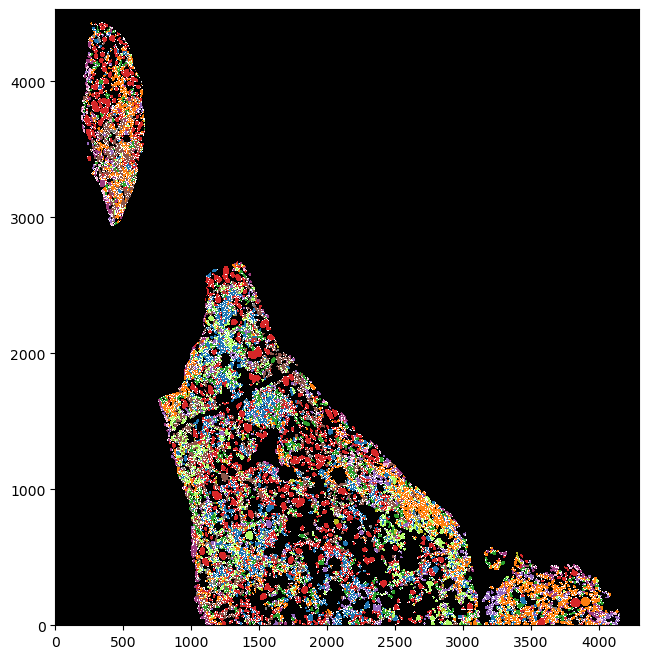

In [9]:
# EDIT ME: pick a real sample name from dat.keys() printed above
sample_to_plot = list(dat.keys())[1]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
_ = (
    dat[sample_to_plot]
    .la.deselect(["Removed"])
    .pl.show(render_image=False, render_segmentation=True, render_labels=True, ax=ax)
)
if ax.get_legend():
    ax.get_legend().remove()

fig.savefig(
    os.path.join(paths["visual_output_dir"], f"celltype_map_{sample_to_plot}.png"),
    dpi=900, bbox_inches="tight",
)


## ROI crops *(template - pixel coordinates are specific to your images)*

Pick a sample, look at its full-image plot above to find a region you want
to crop, then set the pixel ranges below (`dat[sample].pp[row_start:row_end,
col_start:col_end]`). The values below are just placeholders from the
original notebook's example ROIs - replace them with your own.

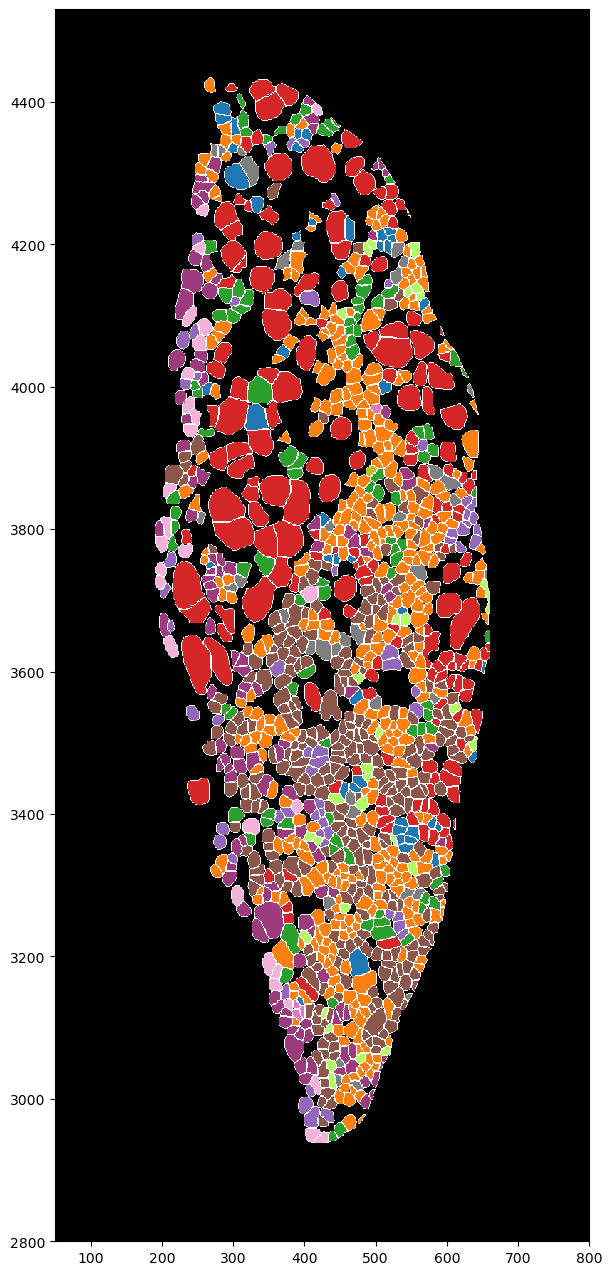

In [10]:
# EDIT ME: sample + pixel ranges for your region of interest
roi_sample = sample_to_plot
roi_row_range = (50, 800)     # placeholder - replace with your own
roi_col_range = (2800, 4800)  # placeholder - replace with your own
roi_name = "ROI1"

roi = dat[roi_sample].pp[roi_row_range[0]:roi_row_range[1], roi_col_range[0]:roi_col_range[1]]

fig, ax = plt.subplots(1, 1, figsize=(10, 16))
_ = roi.la.deselect(["Removed"]).pl.show(render_image=False, render_segmentation=True, render_labels=True, ax=ax)
if ax.get_legend():
    ax.get_legend().remove()
fig.savefig(
    os.path.join(paths["visual_output_dir"], f"{roi_name}_{roi_sample}.png"),
    dpi=900, bbox_inches="tight",
)


In [11]:
# extract just this ROI's cell-type table and save it separately
roi_cell_ids = list(pd.Series(roi.cells))
roi_df = CTs_by_sample[roi_sample][[c in roi_cell_ids for c in CTs_by_sample[roi_sample]["cell"]]]
roi_df.to_csv(os.path.join(FEATURES_OUTPUT_DIR, f"{roi_name}_{roi_sample}_final.csv"))
roi_df.head()


,cell,label
347,348,Megakaryocytes
348,349,Megakaryocytes
349,350,Megakaryocytes
350,351,Megakaryocytes
351,352,Myofibroblasts


## Marker-intensity visualization & filtering *(templates)*

Generic utility functions (unchanged from the original notebook) for
high-value clipping and a two-marker-gated "bone" filter, plus example
visualization cells. Marker names, colors, and thresholds below are
dataset-specific - edit them for your own markers. Note these operate on
the **raw** marker names (with spaces), not the R-safe `anndata.var_names`
form - use `channels` (printed above) as your reference list.

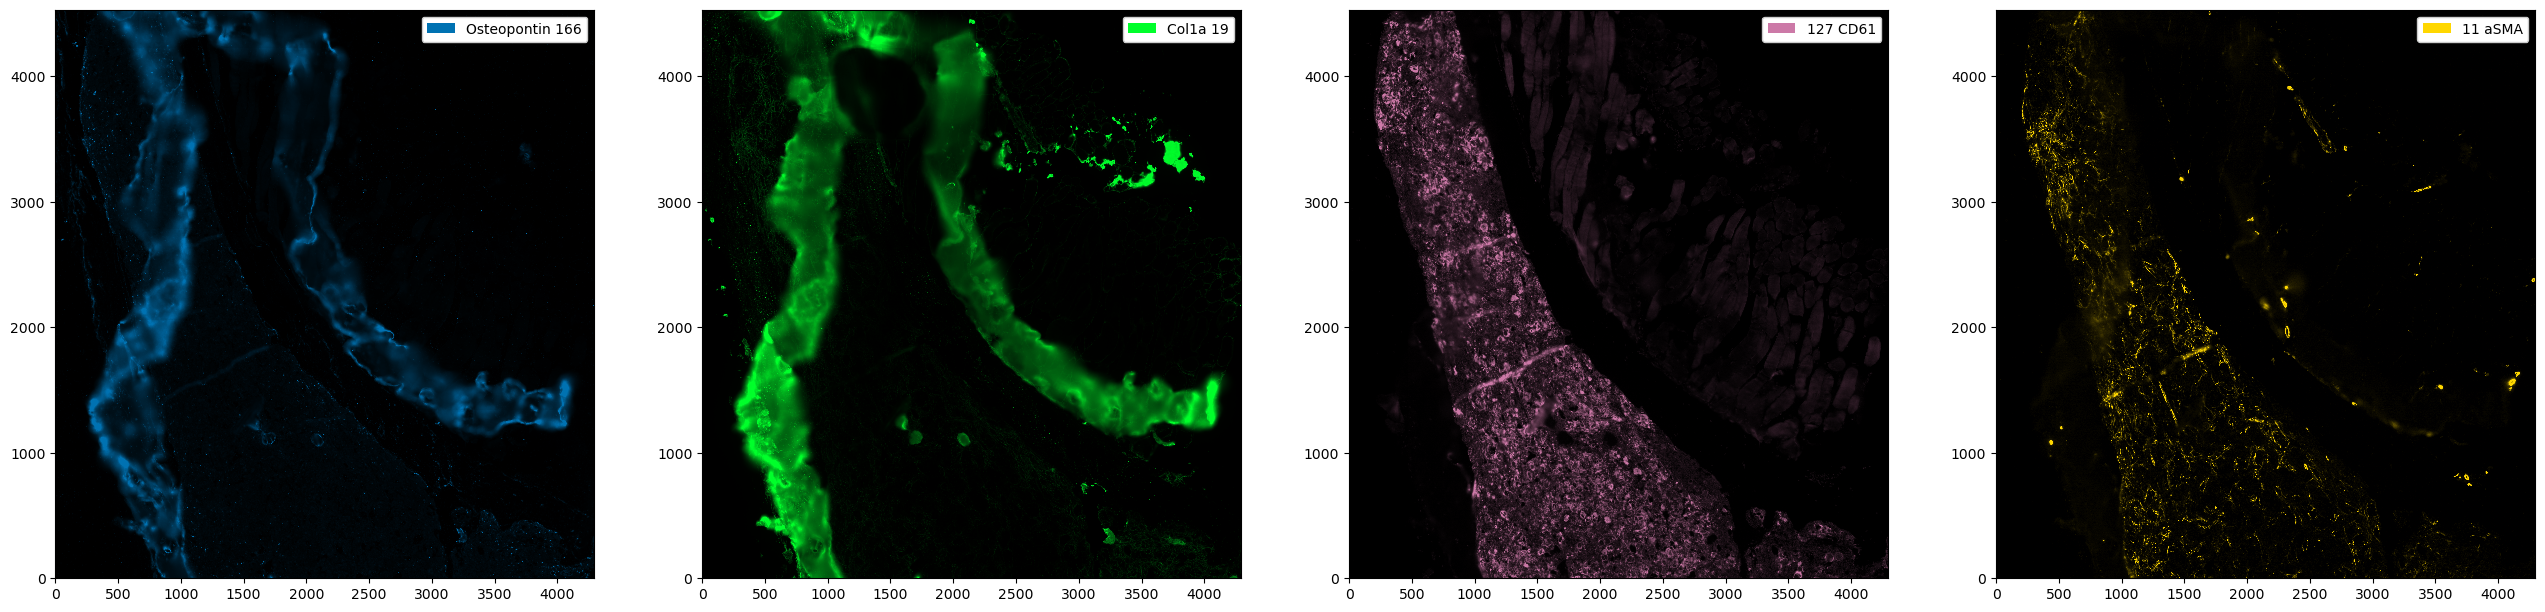

In [12]:
# EDIT ME: raw marker names + colors + thresholds for your visualization.
# `sample_for_markers` should be one of your zarr keys, re-opened fresh
# (not the label-attached `dat[...]` from above) since these operate on
# raw image intensities.
zarr_files_for_markers = sorted(glob(os.path.join(
    paths["zarr_dir"], f"{paths['zarr_prefix']}run{list(condition_vecs.keys())[0]}*.zarr"
)))
ds_full = xr.open_zarr(zarr_files_for_markers[1])

#markers_to_plot = target_columns_raw[:3] if len(target_columns_raw) >= 3 else target_columns_raw  # placeholder
#plot_colors = ["#0072B2", "#00FF2B", "#13F4EF"][: len(markers_to_plot)]

markers_to_plot = ['Osteopontin 166','Col1a 19', '127 CD61', '11 aSMA']
plot_colors = ["#0072B2", "#00FF2B", '#CC79A7', '#FFD700']

fig, ax = plt.subplots(1, len(markers_to_plot), figsize=(8 * len(markers_to_plot), 8))
if len(markers_to_plot) == 1:
    ax = [ax]
for idx, mkr in enumerate(markers_to_plot):
    _ = ds_full.pp[[mkr]].pl.colorize([plot_colors[idx]]).pl.show(ax=ax[idx])


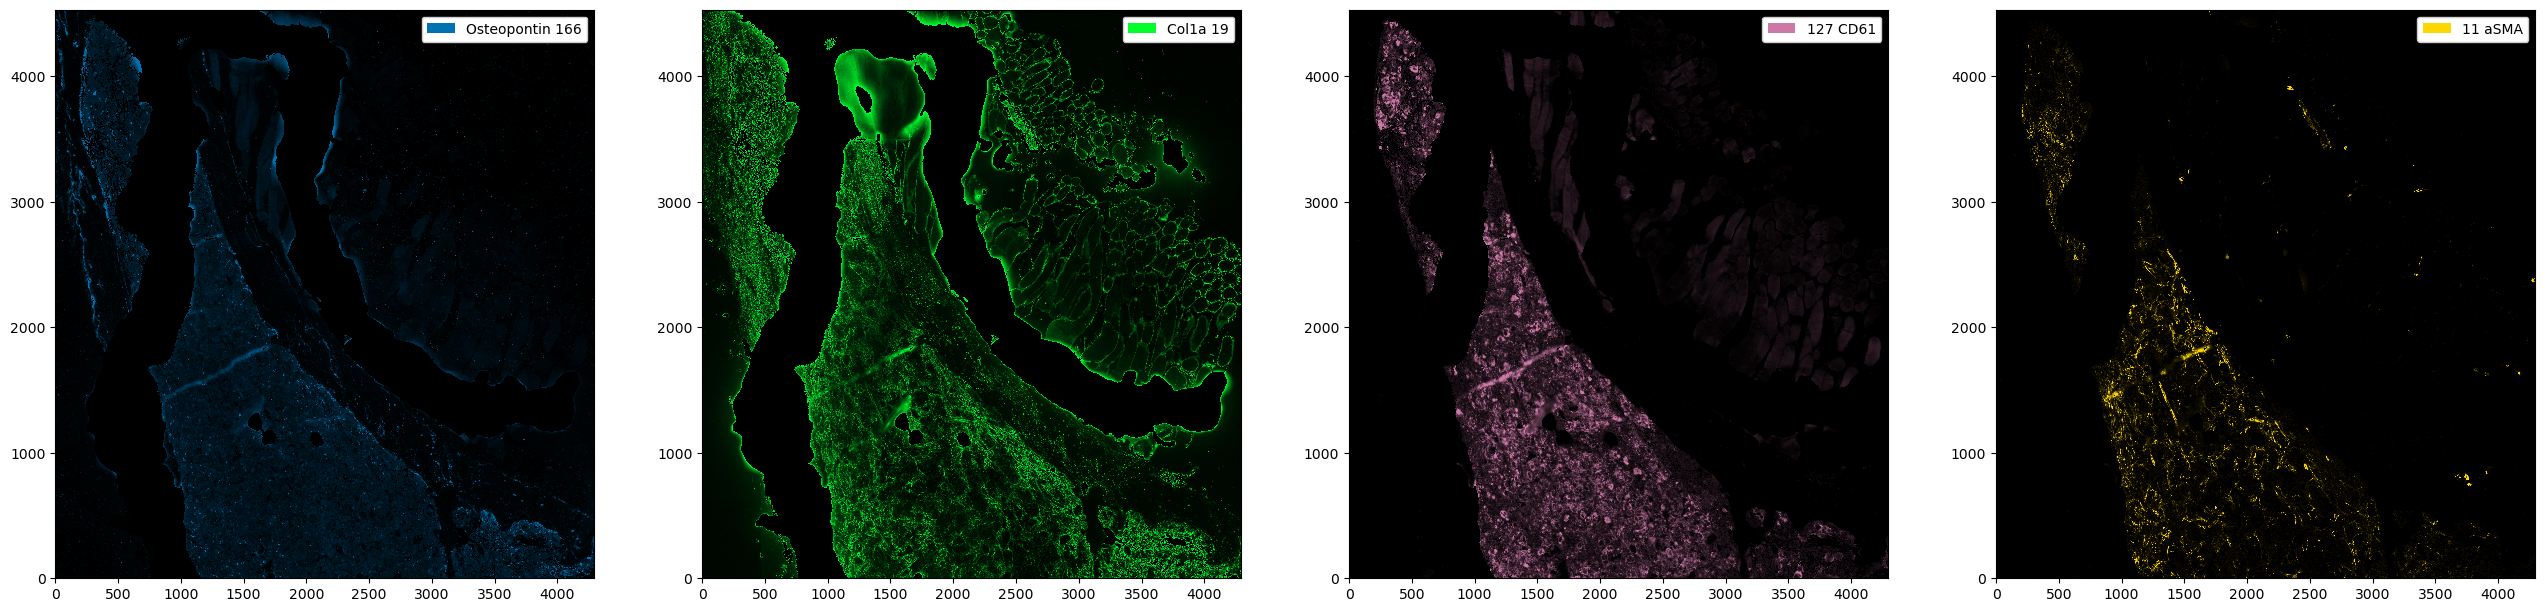

In [13]:
# example: bone filter (Two-marker-gated filter with Collagen and DAPI)

ds_markers=['DAPI']+markers_to_plot
ds=ds_full.pp[ds_markers] # subset
ds=ds.pipe(cah.filter_bone, filts=[ds_markers.index('DAPI'), ds_markers.index('Col1a 19')], cutoffs_q=[0.5,0.75])

fig, ax = plt.subplots(1, len(markers_to_plot), figsize=(8 * len(markers_to_plot), 8))
if len(markers_to_plot) == 1:
    ax = [ax]
for idx, mkr in enumerate(markers_to_plot):
    _ = ds.pp[[mkr]].pl.colorize([plot_colors[idx]]).pl.show(ax=ax[idx])

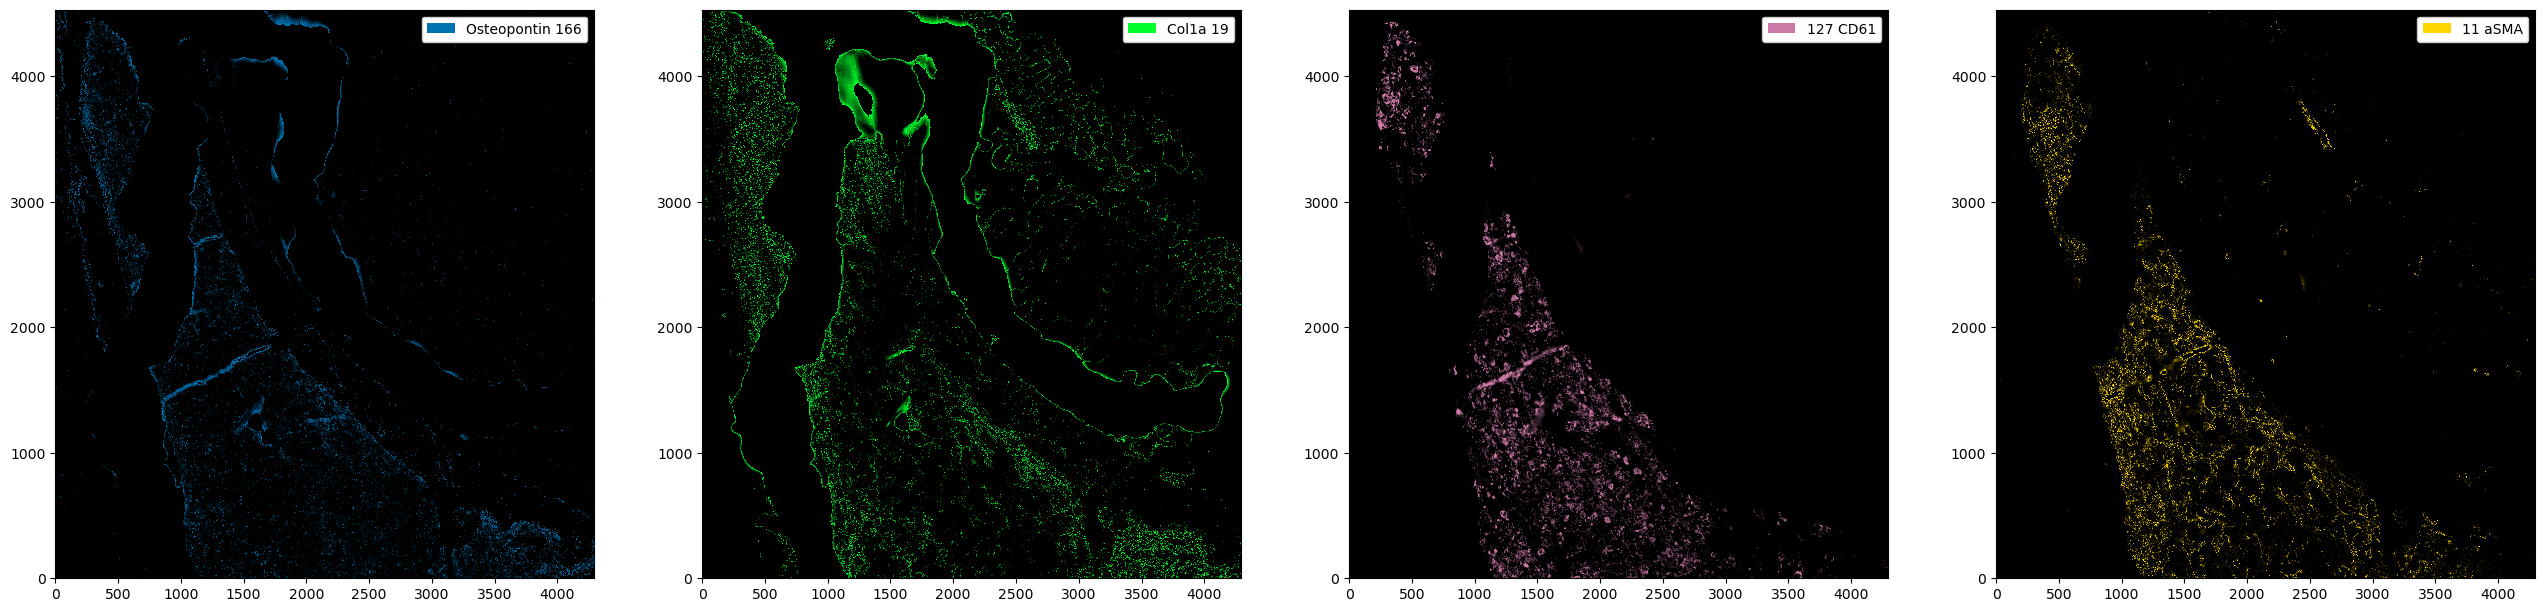

In [14]:
# example: apply high-value clipping + quantile threshold before plotting
#filt_high_q = [0.99] * len(markers_to_plot)   # placeholder - per-marker high-value clip quantile
filt_high_q = [0.99, 0.99, 1, 0.99]
thr_q = [0.9] * len(markers_to_plot)          # placeholder - per-marker display threshold

fig, ax = plt.subplots(1, len(markers_to_plot), figsize=(8 * len(markers_to_plot), 8))
if len(markers_to_plot) == 1:
    ax = [ax]
for idx, mkr in enumerate(markers_to_plot):
    _ = (
        ds.pp[[mkr]]
        .pipe(cah.filter_high, q=filt_high_q[idx])
        .pp.threshold(quantile=thr_q[idx])
        .pl.colorize([plot_colors[idx]])
        .pl.show(ax=ax[idx])
    )


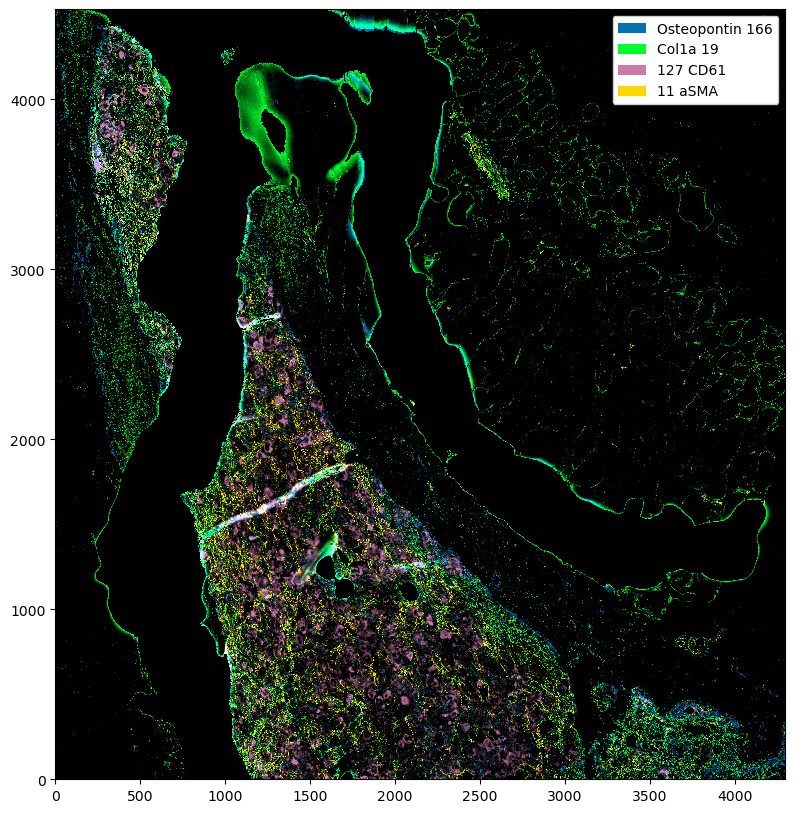

In [15]:
# plot all markers of interest together

plt.figure(figsize=(10, 10))
_ = (ds.pp[markers_to_plot]
                   .pipe(cah.filter_high_multi, quantiles=[0.99, 0.99, 1, 0.99])
                   .pp.threshold(quantile=[0.9, 0.9, 0.9, 0.9])
                   .pl.colorize(plot_colors)
                   .pl.show())

## README

`FEATURES_OUTPUT_DIR` (`pipeline_run/spatial_celltype_features/`) holds one
`cell_features_<sample>.csv` per sample: every cell ever quantified for
that sample (including ones filtered out upstream, labeled `"Removed"`),
with `cell` (1-based label matching the merged segmentation), `label`
(cluster name or `"Removed"`), and your chosen `target_columns_raw`
protein intensities.

`dat` (in-memory, not saved by default) holds one `spatialproteomics`
object per sample with cell-type labels + matching colors attached, ready
for `.la.deselect([...]).pl.show(...)`-style plotting or `.pp[...]`
pixel-range cropping for ROIs.

Figures save to `paths['visual_output_dir']`; ROI cell-type tables save
alongside the per-sample CSVs in `FEATURES_OUTPUT_DIR`.
